LOADING ALL DATASETS

EngSAF Dataset Sizes:
  Train: 3662
  Val: 407
  Unseen Answers: 980
  Unseen Questions: 765

Mohler Dataset Size: 2273

ENGSAF DATASET STRUCTURE

EngSAF Train Columns:
['Question_id', 'Question', 'Student Answer', 'Correct Answer', 'output_label', 'feedback']

Sample from EngSAF Train:
   Question_id                                           Question  \
0          NaN  Q1. State TRUE or FALSE and justify. No correc...   
1     324731.0                 A rating curve is only valid when?   

                                      Student Answer  \
0                                              FALSE   
1  Rating curve is valid only when there is no re...   

                                      Correct Answer  output_label  \
0  False, parent and child processes are two inde...             0   
1  A rating curve is only valid when there is no ...             1   

                                            feedback  
0  Your answer is incorrect. Parent and child p

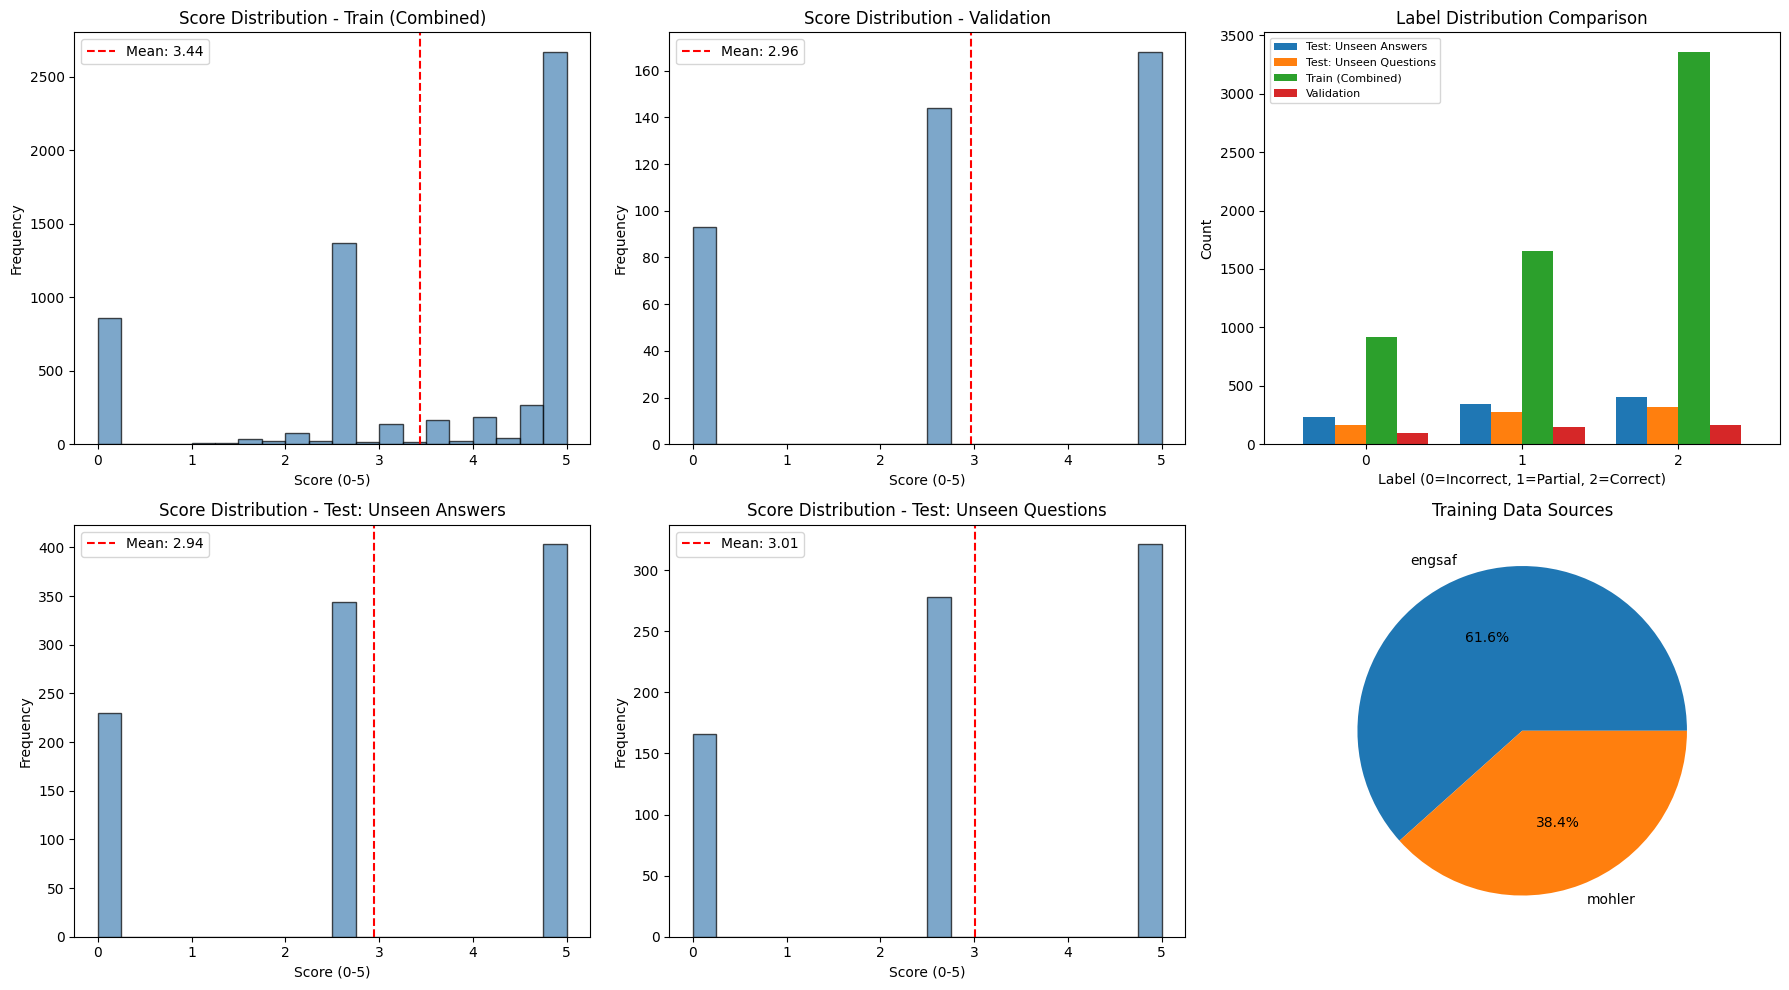


SUMMARY STATISTICS

Train (Combined):
  Total samples: 5923
  Score range: 0.00 - 5.00
  Score mean: 3.44 ± 1.78
  Label distribution:
    Label 0: 914 (15.4%)
    Label 1: 1652 (27.9%)
    Label 2: 3357 (56.7%)
  Avg student answer length: 138 chars
  Avg reference answer length: 152 chars
  Feedback available: 3650/5923 (61.6%)

Validation:
  Total samples: 405
  Score range: 0.00 - 5.00
  Score mean: 2.96 ± 1.96
  Label distribution:
    Label 0: 93 (23.0%)
    Label 1: 144 (35.6%)
    Label 2: 168 (41.5%)
  Avg student answer length: 153 chars
  Avg reference answer length: 193 chars
  Feedback available: 405/405 (100.0%)

Test: Unseen Answers:
  Total samples: 977
  Score range: 0.00 - 5.00
  Score mean: 2.94 ± 1.96
  Label distribution:
    Label 0: 230 (23.5%)
    Label 1: 344 (35.2%)
    Label 2: 403 (41.2%)
  Avg student answer length: 155 chars
  Avg reference answer length: 196 chars
  Feedback available: 977/977 (100.0%)

Test: Unseen Questions:
  Total samples: 765
  Scor

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# STEP 1: LOAD ALL ENGSAF DATASETS
# ============================================================

print("="*60)
print("LOADING ALL DATASETS")
print("="*60)

# EngSAF datasets
engsaf_train = pd.read_csv("data/EngSAF dataset/train.csv")
engsaf_val = pd.read_csv("data/EngSAF dataset/val.csv")
engsaf_unseen_answers = pd.read_csv("data/EngSAF dataset/unseen_answers.csv")
engsaf_unseen_questions = pd.read_csv("data/EngSAF dataset/unseen_question.csv")

# Mohler dataset
mohler = pd.read_csv('data/mohler_dataset_edited.csv')

print("\nEngSAF Dataset Sizes:")
print(f"  Train: {len(engsaf_train)}")
print(f"  Val: {len(engsaf_val)}")
print(f"  Unseen Answers: {len(engsaf_unseen_answers)}")
print(f"  Unseen Questions: {len(engsaf_unseen_questions)}")
print(f"\nMohler Dataset Size: {len(mohler)}")

# ============================================================
# STEP 2: INSPECT ENGSAF COLUMNS
# ============================================================

print("\n" + "="*60)
print("ENGSAF DATASET STRUCTURE")
print("="*60)

print("\nEngSAF Train Columns:")
print(engsaf_train.columns.tolist())

print("\nSample from EngSAF Train:")
print(engsaf_train.head(2))

print("\nEngSAF Label Distribution:")
for name, df in [('Train', engsaf_train), ('Val', engsaf_val), 
                  ('Unseen Answers', engsaf_unseen_answers), 
                  ('Unseen Questions', engsaf_unseen_questions)]:
    print(f"\n{name}:")
    print(df['output_label'].value_counts().sort_index())

# ============================================================
# STEP 3: NORMALIZE ALL DATASETS TO COMMON FORMAT
# ============================================================

def normalize_engsaf(df, dataset_name):
    """Normalize EngSAF dataset to common format"""
    df_normalized = df.copy()
    
    # Rename columns to match our format
    column_mapping = {
        'Question': 'question',
        'Student Answer': 'student_answer',
        'Correct Answer': 'reference_answer',
        'output_label': 'label',
        'feedback': 'feedback',
        'Question_id': 'question_id'
    }
    
    # Handle different possible column names
    for old_name, new_name in column_mapping.items():
        if old_name in df.columns:
            df_normalized = df_normalized.rename(columns={old_name: new_name})
    
    # Map labels to scores (0 → 0, 1 → 2.5, 2 → 5)
    if 'label' in df_normalized.columns:
        label_to_score = {0: 0.0, 1: 2.5, 2: 5.0}
        df_normalized['score'] = df_normalized['label'].map(label_to_score)
    
    # Add metadata
    df_normalized['dataset_source'] = 'engsaf'
    df_normalized['dataset_split'] = dataset_name
    
    # Ensure all required columns exist
    required_cols = ['question', 'student_answer', 'reference_answer', 'score', 'label']
    for col in required_cols:
        if col not in df_normalized.columns:
            print(f"⚠️ Warning: {col} not found in {dataset_name}")
    
    return df_normalized

def normalize_mohler(df):
    """Normalize Mohler dataset to common format"""
    df_normalized = df.copy()
    
    # Rename columns
    df_normalized = df_normalized.rename(columns={
        'question': 'question',
        'desired_answer': 'reference_answer',
        'student_answer': 'student_answer',
        'score_avg': 'score'
    })
    
    # Convert score to 0-5 range (check what range Mohler uses)
    # Mohler typically uses 0-5, but let's verify
    max_score = df_normalized['score'].max()
    if max_score > 5:
        df_normalized['score'] = (df_normalized['score'] / max_score) * 5
    
    # Map scores to labels
    df_normalized['label'] = pd.cut(
        df_normalized['score'], 
        bins=[-0.1, 1.67, 3.33, 5.1], 
        labels=[0, 1, 2]
    )
    
    # Mohler doesn't have feedback
    df_normalized['feedback'] = ''
    df_normalized['question_id'] = range(len(df_normalized))
    
    # Add metadata
    df_normalized['dataset_source'] = 'mohler'
    df_normalized['dataset_split'] = 'mohler_original'
    
    return df_normalized

# Normalize all datasets
print("\n" + "="*60)
print("NORMALIZING ALL DATASETS")
print("="*60)

engsaf_train_norm = normalize_engsaf(engsaf_train, 'train')
engsaf_val_norm = normalize_engsaf(engsaf_val, 'val')
engsaf_ua_norm = normalize_engsaf(engsaf_unseen_answers, 'unseen_answers')
engsaf_uq_norm = normalize_engsaf(engsaf_unseen_questions, 'unseen_questions')
mohler_norm = normalize_mohler(mohler)

print("✅ All datasets normalized")

# ============================================================
# STEP 4: DATA QUALITY CHECK & CLEANING
# ============================================================

def clean_dataset(df, name):
    """Clean dataset by removing invalid entries"""
    print(f"\nCleaning {name}...")
    print(f"  Initial size: {len(df)}")
    
    df_clean = df.copy()
    
    # Remove rows with missing critical data
    critical_cols = ['question', 'student_answer', 'reference_answer', 'score', 'label']
    
    for col in critical_cols:
        if col in df_clean.columns:
            # Remove nulls
            before = len(df_clean)
            df_clean = df_clean[df_clean[col].notna()]
            after = len(df_clean)
            if before != after:
                print(f"  Removed {before - after} rows with null {col}")
            
            # Remove empty strings (for text columns)
            if col in ['question', 'student_answer', 'reference_answer']:
                before = len(df_clean)
                df_clean = df_clean[df_clean[col].astype(str).str.strip() != '']
                after = len(df_clean)
                if before != after:
                    print(f"  Removed {before - after} rows with empty {col}")
    
    # Remove invalid scores
    before = len(df_clean)
    df_clean = df_clean[(df_clean['score'] >= 0) & (df_clean['score'] <= 5)]
    after = len(df_clean)
    if before != after:
        print(f"  Removed {before - after} rows with invalid scores")
    
    # Remove invalid labels
    before = len(df_clean)
    df_clean = df_clean[df_clean['label'].isin([0, 1, 2])]
    after = len(df_clean)
    if before != after:
        print(f"  Removed {before - after} rows with invalid labels")
    
    print(f"  Final size: {len(df_clean)}")
    print(f"  Removed: {len(df) - len(df_clean)} rows ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")
    
    return df_clean.reset_index(drop=True)

# Clean all datasets
engsaf_train_clean = clean_dataset(engsaf_train_norm, 'EngSAF Train')
engsaf_val_clean = clean_dataset(engsaf_val_norm, 'EngSAF Val')
engsaf_ua_clean = clean_dataset(engsaf_ua_norm, 'EngSAF Unseen Answers')
engsaf_uq_clean = clean_dataset(engsaf_uq_norm, 'EngSAF Unseen Questions')
mohler_clean = clean_dataset(mohler_norm, 'Mohler')

# ============================================================
# STEP 5: CREATE TRAINING STRATEGY
# ============================================================

print("\n" + "="*60)
print("CREATING DATASET SPLITS")
print("="*60)

# Select common columns
common_columns = [
    'question', 'student_answer', 'reference_answer', 
    'score', 'label', 'feedback', 'question_id',
    'dataset_source', 'dataset_split'
]

# Ensure all datasets have these columns
for df_name, df in [
    ('engsaf_train_clean', engsaf_train_clean),
    ('engsaf_val_clean', engsaf_val_clean),
    ('mohler_clean', mohler_clean)
]:
    for col in common_columns:
        if col not in df.columns:
            df[col] = '' if col == 'feedback' else 0

# Strategy 1: Use EngSAF splits + Mohler augmentation
# Train = EngSAF Train + Mohler
# Val = EngSAF Val
# Test1 = EngSAF Unseen Answers
# Test2 = EngSAF Unseen Questions

train_combined = pd.concat([
    engsaf_train_clean[common_columns],
    mohler_clean[common_columns]
], ignore_index=True)

val_combined = engsaf_val_clean[common_columns].copy()
test_unseen_answers = engsaf_ua_clean[common_columns].copy()
test_unseen_questions = engsaf_uq_clean[common_columns].copy()

print("\nFinal Dataset Sizes:")
print(f"  Train (EngSAF + Mohler): {len(train_combined)}")
print(f"    - EngSAF: {len(engsaf_train_clean)}")
print(f"    - Mohler: {len(mohler_clean)}")
print(f"  Validation: {len(val_combined)}")
print(f"  Test - Unseen Answers: {len(test_unseen_answers)}")
print(f"  Test - Unseen Questions: {len(test_unseen_questions)}")

print("\nLabel Distribution in Training Set:")
print(train_combined['label'].value_counts().sort_index())

print("\nDataset Source Distribution in Training Set:")
print(train_combined['dataset_source'].value_counts())

# ============================================================
# STEP 6: SAVE PROCESSED DATASETS
# ============================================================

# Create output directory
import os
os.makedirs('processed_data', exist_ok=True)

train_combined.to_csv('processed_data/train_combined.csv', index=False)
val_combined.to_csv('processed_data/val_combined.csv', index=False)
test_unseen_answers.to_csv('processed_data/test_unseen_answers.csv', index=False)
test_unseen_questions.to_csv('processed_data/test_unseen_questions.csv', index=False)

print("\n✅ Saved processed datasets to 'processed_data/' folder")

# ============================================================
# STEP 7: ANALYZE QUESTION OVERLAP
# ============================================================

print("\n" + "="*60)
print("QUESTION OVERLAP ANALYSIS")
print("="*60)

# Extract unique questions from each split
train_questions = set(engsaf_train_clean['question_id'].unique())
val_questions = set(engsaf_val_clean['question_id'].unique()) if 'question_id' in engsaf_val_clean.columns else set()
ua_questions = set(engsaf_ua_clean['question_id'].unique()) if 'question_id' in engsaf_ua_clean.columns else set()
uq_questions = set(engsaf_uq_clean['question_id'].unique()) if 'question_id' in engsaf_uq_clean.columns else set()

print(f"\nUnique Questions:")
print(f"  Train: {len(train_questions)}")
print(f"  Val: {len(val_questions)}")
print(f"  Unseen Answers: {len(ua_questions)}")
print(f"  Unseen Questions: {len(uq_questions)}")

if ua_questions:
    overlap_ua = len(train_questions.intersection(ua_questions))
    print(f"\nUnseen Answers - Question Overlap with Train: {overlap_ua}/{len(ua_questions)} ({overlap_ua/len(ua_questions)*100:.1f}%)")
    print(f"  ✅ This is EXPECTED - same questions, different student answers")

if uq_questions:
    overlap_uq = len(train_questions.intersection(uq_questions))
    print(f"\nUnseen Questions - Question Overlap with Train: {overlap_uq}/{len(uq_questions)} ({overlap_uq/len(uq_questions)*100:.1f}%)")
    print(f"  ✅ This should be 0% - completely new questions")

# ============================================================
# STEP 8: VISUALIZE DATA DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    ('Train (Combined)', train_combined),
    ('Validation', val_combined),
    ('Test: Unseen Answers', test_unseen_answers),
    ('Test: Unseen Questions', test_unseen_questions)
]

# Plot 1-4: Score distributions
for idx, (name, df) in enumerate(datasets):
    row = idx // 2
    col = idx % 2
    
    axes[row, col].hist(df['score'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Score Distribution - {name}')
    axes[row, col].set_xlabel('Score (0-5)')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].axvline(df['score'].mean(), color='red', linestyle='--', 
                            label=f'Mean: {df["score"].mean():.2f}')
    axes[row, col].legend()

# Plot 5: Label distribution comparison
label_data = []
for name, df in datasets:
    for label in [0, 1, 2]:
        count = (df['label'] == label).sum()
        label_data.append({'Dataset': name, 'Label': label, 'Count': count})

label_df = pd.DataFrame(label_data)
pivot_df = label_df.pivot(index='Label', columns='Dataset', values='Count')
pivot_df.plot(kind='bar', ax=axes[0, 2], width=0.8)
axes[0, 2].set_title('Label Distribution Comparison')
axes[0, 2].set_xlabel('Label (0=Incorrect, 1=Partial, 2=Correct)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend(loc='best', fontsize=8)
axes[0, 2].set_xticklabels(['0', '1', '2'], rotation=0)

# Plot 6: Dataset source in training
train_combined['dataset_source'].value_counts().plot(kind='pie', ax=axes[1, 2], autopct='%1.1f%%')
axes[1, 2].set_title('Training Data Sources')
axes[1, 2].set_ylabel('')

plt.tight_layout()
plt.savefig('processed_data/dataset_analysis.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved visualization to 'processed_data/dataset_analysis.png'")
plt.show()

# ============================================================
# STEP 9: SUMMARY STATISTICS
# ============================================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

for name, df in datasets:
    print(f"\n{name}:")
    print(f"  Total samples: {len(df)}")
    print(f"  Score range: {df['score'].min():.2f} - {df['score'].max():.2f}")
    print(f"  Score mean: {df['score'].mean():.2f} ± {df['score'].std():.2f}")
    print(f"  Label distribution:")
    for label in [0, 1, 2]:
        count = (df['label'] == label).sum()
        pct = count / len(df) * 100
        print(f"    Label {label}: {count} ({pct:.1f}%)")
    
    print(f"  Avg student answer length: {df['student_answer'].str.len().mean():.0f} chars")
    print(f"  Avg reference answer length: {df['reference_answer'].str.len().mean():.0f} chars")
    
    # Check for feedback availability
    if 'feedback' in df.columns:
        feedback_available = (df['feedback'].notna() & (df['feedback'].astype(str).str.strip() != '')).sum()
        print(f"  Feedback available: {feedback_available}/{len(df)} ({feedback_available/len(df)*100:.1f}%)")

print("\n" + "="*60)
print("✅ DATA PREPARATION COMPLETE!")
print("="*60)
print("\nNext steps:")
print("1. Extract features from the combined datasets")
print("2. Train the model on train_combined.csv")
print("3. Validate on val_combined.csv")
print("4. Test on BOTH test sets:")
print("   - test_unseen_answers.csv (same questions, new answers)")
print("   - test_unseen_questions.csv (completely new questions)")
print("\nThis will give you a comprehensive evaluation of model generalization!")

In [9]:
# ============================================================
# FEATURE EXTRACTION FOR ALL DATASETS
# ============================================================

import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

class AnswerFeatureExtractor:
    """Extract similarity features - Simplified version"""
    
    def __init__(self):
        self.stop_words = {
            'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
            'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were', 'been',
            'be', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
            'should', 'could', 'may', 'might', 'must', 'can', 'this', 'that'
        }
        self.tfidf_vectorizer = TfidfVectorizer(max_features=5000)
        
    def preprocess_text(self, text):
        if pd.isna(text):
            return ""
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
        text = ' '.join(text.split())
        return text
    
    def get_keywords(self, text, top_n=10):
        text = self.preprocess_text(text)
        tokens = text.split()
        keywords = [word for word in tokens if word not in self.stop_words and len(word) > 2]
        return set(keywords[:top_n])
    
    def keyword_overlap(self, student_answer, reference_answer):
        try:
            student_kw = self.get_keywords(student_answer)
            reference_kw = self.get_keywords(reference_answer)
            
            if len(reference_kw) == 0:
                return 0.0
            
            overlap = len(student_kw.intersection(reference_kw))
            return overlap / len(reference_kw)
        except:
            return 0.0
    
    def cosine_similarity_tfidf(self, student_answer, reference_answer):
        try:
            student_text = self.preprocess_text(student_answer)
            reference_text = self.preprocess_text(reference_answer)
            
            if not student_text or not reference_text:
                return 0.0
            
            vectors = self.tfidf_vectorizer.fit_transform([reference_text, student_text])
            similarity = cosine_similarity(vectors[0:1], vectors[1:2])[0][0]
            return similarity
        except:
            return 0.0
    
    def length_ratio(self, student_answer, reference_answer):
        try:
            student_len = len(str(student_answer).split())
            reference_len = len(str(reference_answer).split())
            
            if reference_len == 0:
                return 0.0
            
            ratio = student_len / reference_len
            if ratio > 1:
                return 1 / ratio
            return ratio
        except:
            return 0.0
    
    def extract_all_features(self, row):
        try:
            student_ans = row['student_answer']
            reference_ans = row['reference_answer']
            
            features = {
                'keyword_overlap': self.keyword_overlap(student_ans, reference_ans),
                'cosine_similarity': self.cosine_similarity_tfidf(student_ans, reference_ans),
                'length_ratio': self.length_ratio(student_ans, reference_ans),
                'student_length': len(str(student_ans).split()),
                'reference_length': len(str(reference_ans).split()),
            }
            
            return features
        except:
            return {
                'keyword_overlap': 0.0,
                'cosine_similarity': 0.0,
                'length_ratio': 0.0,
                'student_length': 0,
                'reference_length': 0,
            }

def add_features_to_df(df, name):
    """Add all features to dataframe"""
    print(f"\nExtracting features for {name} ({len(df)} samples)...")
    
    feature_extractor = AnswerFeatureExtractor()
    features_list = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {name}"):
        features = feature_extractor.extract_all_features(row)
        features_list.append(features)
    
    features_df = pd.DataFrame(features_list)
    result_df = pd.concat([df.reset_index(drop=True), features_df], axis=1)
    
    print(f"✅ Feature extraction complete for {name}")
    return result_df

# Extract features for all datasets
print("\n" + "="*60)
print("EXTRACTING FEATURES FOR ALL DATASETS")
print("="*60)

train_features = add_features_to_df(train_combined, "Train")
val_features = add_features_to_df(val_combined, "Validation")
test_ua_features = add_features_to_df(test_unseen_answers, "Test Unseen Answers")
test_uq_features = add_features_to_df(test_unseen_questions, "Test Unseen Questions")

# Save with features
train_features.to_csv('processed_data/train_combined_features.csv', index=False)
val_features.to_csv('processed_data/val_combined_features.csv', index=False)
test_ua_features.to_csv('processed_data/test_unseen_answers_features.csv', index=False)
test_uq_features.to_csv('processed_data/test_unseen_questions_features.csv', index=False)

print("\n✅ All datasets with features saved to 'processed_data/' folder")

print("\n" + "="*60)
print("FEATURE STATISTICS")
print("="*60)

feature_cols = ['keyword_overlap', 'cosine_similarity', 'length_ratio']
for name, df in [('Train', train_features), ('Val', val_features), 
                  ('Test UA', test_ua_features), ('Test UQ', test_uq_features)]:
    print(f"\n{name}:")
    print(df[feature_cols].describe())


EXTRACTING FEATURES FOR ALL DATASETS

Extracting features for Train (5923 samples)...


Processing Train: 100%|██████████| 5923/5923 [00:06<00:00, 891.93it/s] 


✅ Feature extraction complete for Train

Extracting features for Validation (405 samples)...


Processing Validation: 100%|██████████| 405/405 [00:00<00:00, 857.97it/s]


✅ Feature extraction complete for Validation

Extracting features for Test Unseen Answers (977 samples)...


Processing Test Unseen Answers: 100%|██████████| 977/977 [00:01<00:00, 898.19it/s]


✅ Feature extraction complete for Test Unseen Answers

Extracting features for Test Unseen Questions (765 samples)...


Processing Test Unseen Questions: 100%|██████████| 765/765 [00:00<00:00, 966.58it/s] 


✅ Feature extraction complete for Test Unseen Questions

✅ All datasets with features saved to 'processed_data/' folder

FEATURE STATISTICS

Train:
       keyword_overlap  cosine_similarity  length_ratio
count      5923.000000        5923.000000   5923.000000
mean          0.280760           0.287376      0.588314
std           0.269816           0.220629      0.258870
min           0.000000           0.000000      0.007246
25%           0.100000           0.128683      0.395153
50%           0.222222           0.240983      0.600000
75%           0.400000           0.386449      0.800000
max           1.000000           1.000000      1.000000

Val:
       keyword_overlap  cosine_similarity  length_ratio
count       405.000000         405.000000    405.000000
mean          0.230197           0.267946      0.590708
std           0.231889           0.213646      0.262097
min           0.000000           0.000000      0.026316
25%           0.100000           0.119338      0.394737
50%   

LOADING DATASETS

Dataset sizes:
  Train: 5,923
  Validation: 405
  Test - Unseen Answers: 977
  Test - Unseen Questions: 765

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU

INITIALIZING MODEL & DATA LOADERS

DataLoaders ready:
  Train: 371 batches
  Val: 26 batches
  Test UA: 62 batches
  Test UQ: 48 batches


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 765.49it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model parameters: 109,765,413

Class weights: [2.1601021  1.195117   0.58812433]

Training steps: 1855 (warmup: 185)

TRAINING

Epoch 1/5


Training: 100%|██████████| 371/371 [03:26<00:00,  1.79it/s, loss=0.3302]



Train Loss: 0.4382 | Pred Std: 0.0631

Evaluating...

Dataset                QWK      Pearson  MAE      RMSE     Acc     
----------------------------------------------------------------------
Validation             0.2711   0.2913   1.6340   1.9138   0.5259  
Test: Unseen Answers   0.3649   0.4391   1.5693   1.8197   0.5466  
Test: Unseen Questions 0.3840   0.4715   1.5433   1.7794   0.4771  

✅ Saved best model (Avg QWK: 0.3400)

Epoch 2/5


...


Train Loss: 0.2151 | Pred Std: 0.2321

Evaluating...

Dataset                QWK      Pearson  MAE      RMSE     Acc     
----------------------------------------------------------------------
Validation             0.6844   0.7044   1.1742   1.4021   0.7210  
Test: Unseen Answers   0.6952   0.7356   1.1563   1.3604   0.7032  
Test: Unseen Questions 0.4358   0.5564   1.5573   1.8499   0.4771  

✅ Saved best model (Avg QWK: 0.6051)

Epoch 4/5


Training: 100%|██████████| 371/371 [03:34<00:00,  1.73it/s, loss=0.3103]



Train Loss: 0.1727 | Pred Std: 0.2641

Evaluating...

Dataset                QWK      Pearson  MAE      RMSE     Acc     
----------------------------------------------------------------------
Validation             0.7383   0.7394   1.0835   1.3254   0.7531  
Test: Unseen Answers   0.7695   0.7846   1.0327   1.2390   0.7605  
Test: Unseen Questions 0.5078   0.5652   1.3968   1.6952   0.5451  

✅ Saved best model (Avg QWK: 0.6719)

Epoch 5/5


Training: 100%|██████████| 371/371 [03:34<00:00,  1.73it/s, loss=0.4405]



Train Loss: 0.1498 | Pred Std: 0.2830

Evaluating...

Dataset                QWK      Pearson  MAE      RMSE     Acc     
----------------------------------------------------------------------
Validation             0.7324   0.7553   1.0286   1.2889   0.7457  
Test: Unseen Answers   0.7695   0.7984   0.9842   1.2050   0.7584  
Test: Unseen Questions 0.4705   0.5659   1.4598   1.8021   0.5085  

FINAL EVALUATION (BEST MODEL)

Evaluating on all test sets...

Metric          Validation   Unseen Ans   Unseen Q    
QWK             0.7383       0.7695       0.5078      
Pearson         0.7394       0.7846       0.5652      
Spearman        0.7439       0.7789       0.5829      
MAE             1.0835       1.0327       1.3968      
RMSE            1.3254       1.2390       1.6952      
Accuracy        0.7531       0.7605       0.5451      

✅ Saved predictions to CSV files

✅ Saved visualization: final_results.png


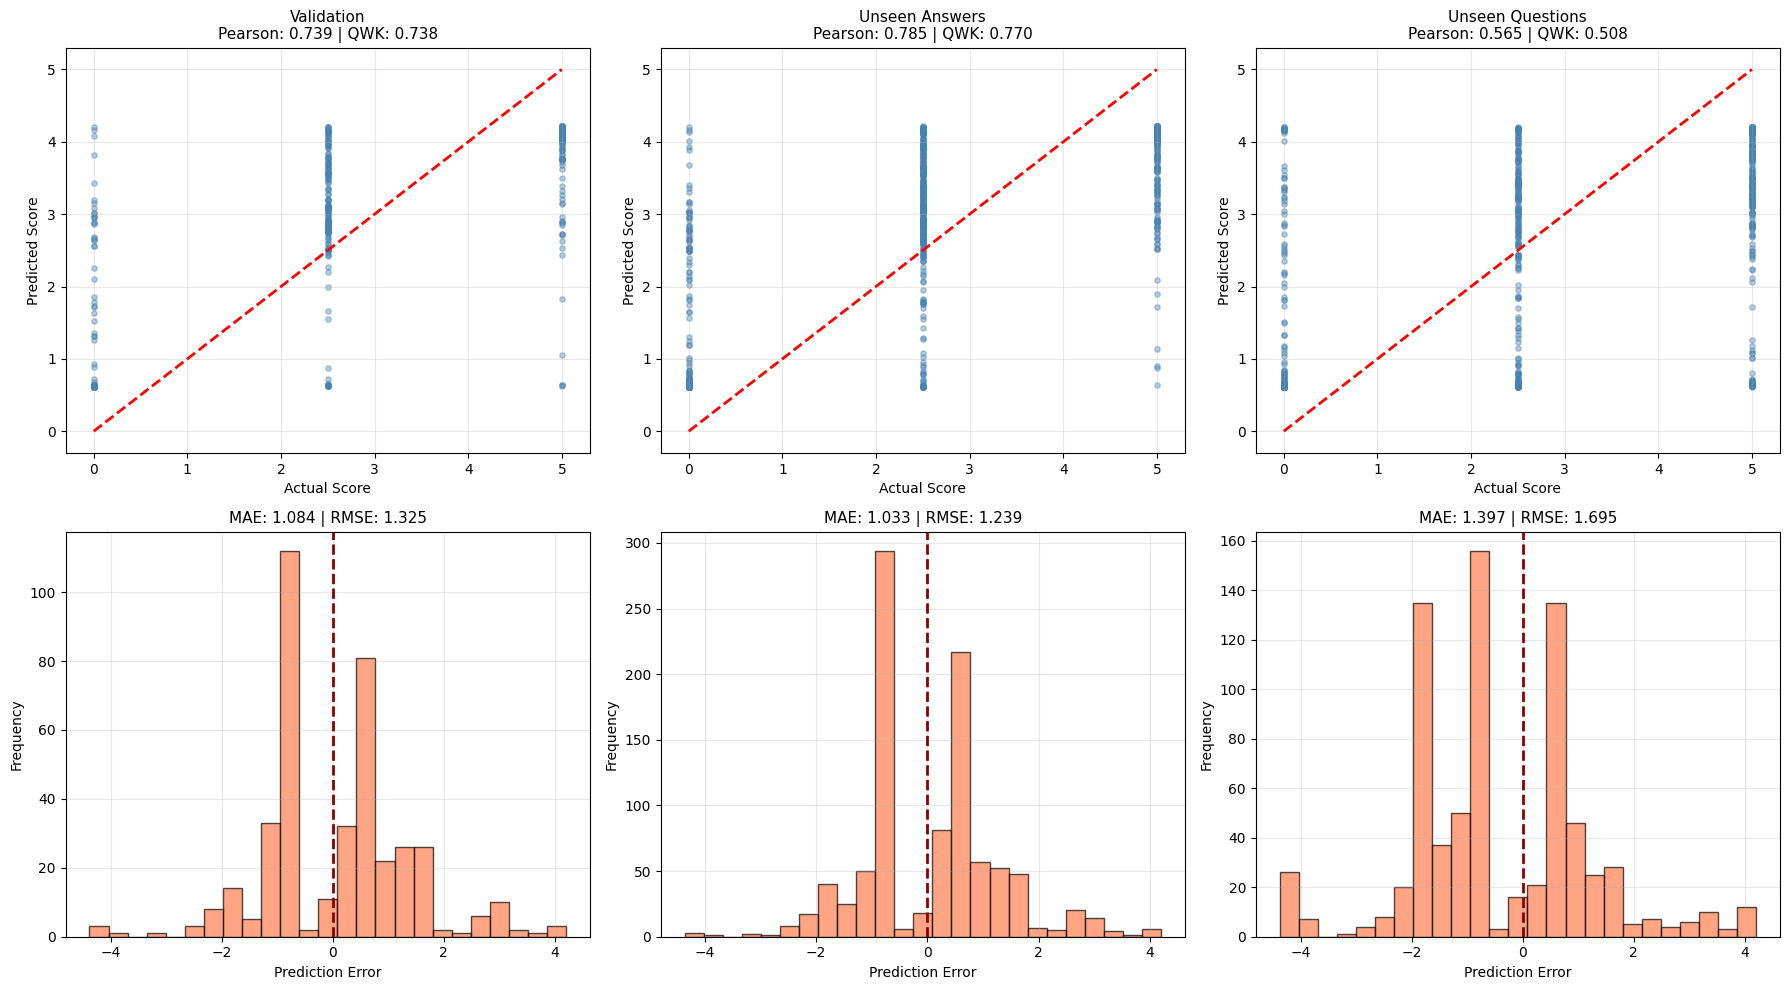


SAMPLE PREDICTIONS

UNSEEN ANSWERS
----------------------------------------------------------------------

✅ Question: Two      advantages of separating declaration from definition are: ........
   Student: 1.) When declaration is separated from definition, then names of all the member functions inside a p...
   Reference: The code will be more clear and easier for the reader to understand. Allows easy...
   Actual: Score=2.50, Label=1
   Predicted: Score=2.91, Label=1
   Error: 0.41
   Feedback:   Your answer acknowledges that separating declaration from definition improves code clarity by organizing member functi...

✅ Question: Quote any one advantage of reservoir and channel flood routing each....
   Student: reservoir routing to design the capacity of spillway and channel routing is used to get flood hydrog...
   Reference: Reservoir Routing: Can be used to estimate peak reservoir levels during flood an...
   Actual: Score=2.50, Label=1
   Predicted: Score=2.90, Label=1
   Error:

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
import warnings
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from scipy.stats import pearsonr, spearmanr
from collections import Counter
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================

CONFIG = {
    'model_name': 'bert-base-uncased',
    'max_length': 384,
    'batch_size': 16,
    'epochs': 5,
    'learning_rate': 2e-5,
    'warmup_ratio': 0.1,
    'dropout': 0.3,
    'alpha': 0.6,  # Weight for regression loss
}

# ============================================================
# LOAD DATA
# ============================================================

print("="*70)
print("LOADING DATASETS")
print("="*70)

train_df = pd.read_csv('processed_data/train_combined_features.csv')
val_df = pd.read_csv('processed_data/val_combined_features.csv')
test_ua_df = pd.read_csv('processed_data/test_unseen_answers_features.csv')
test_uq_df = pd.read_csv('processed_data/test_unseen_questions_features.csv')

print(f"\nDataset sizes:")
print(f"  Train: {len(train_df):,}")
print(f"  Validation: {len(val_df):,}")
print(f"  Test - Unseen Answers: {len(test_ua_df):,}")
print(f"  Test - Unseen Questions: {len(test_uq_df):,}")

# Normalize scores to 0-1
def normalize_scores(df):
    df = df.copy()
    df['score_original'] = df['score']
    df['score'] = df['score'] / 5.0
    return df

train_df = normalize_scores(train_df)
val_df = normalize_scores(val_df)
test_ua_df = normalize_scores(test_ua_df)
test_uq_df = normalize_scores(test_uq_df)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ============================================================
# DATASET CLASS
# ============================================================

class AnswerEvaluationDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=384):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        question = str(row['question'])[:250]
        reference = str(row['reference_answer'])[:350]
        student = str(row['student_answer'])[:350]
        
        combined_text = f"Question: {question} | Reference: {reference} | Student: {student}"
        
        encoding = self.tokenizer(
            combined_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        features = torch.tensor([
            float(row.get('keyword_overlap', 0.0)),
            float(row.get('cosine_similarity', 0.0)),
            float(row.get('length_ratio', 0.0)),
        ], dtype=torch.float)
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'features': features,
            'score': torch.tensor(row['score'], dtype=torch.float),
            'label': torch.tensor(int(row['label']), dtype=torch.long)
        }

# ============================================================
# MODEL ARCHITECTURE
# ============================================================

class AnswerEvaluationModel(nn.Module):
    def __init__(self, model_name='bert-base-uncased', num_features=3, dropout=0.3):
        super(AnswerEvaluationModel, self).__init__()
        
        self.bert = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.bert.config.hidden_size
        
        # Feature network
        self.feature_net = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # Attention pooling
        self.attention = nn.Linear(self.hidden_size, 1)
        
        # Shared layers
        self.shared = nn.Sequential(
            nn.Linear(self.hidden_size + 32, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 3)
        )
    
    def forward(self, input_ids, attention_mask, features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        
        # Attention pooling
        attention_weights = torch.softmax(self.attention(sequence_output), dim=1)
        attended = torch.sum(attention_weights * sequence_output, dim=1)
        
        # Process features
        feature_output = self.feature_net(features)
        
        # Combine
        combined = torch.cat([attended, feature_output], dim=1)
        shared = self.shared(combined)
        
        score_pred = self.regressor(shared).squeeze(-1)
        label_logits = self.classifier(shared)
        
        return score_pred, label_logits

# ============================================================
# DATA LOADERS
# ============================================================

print("\n" + "="*70)
print("INITIALIZING MODEL & DATA LOADERS")
print("="*70)

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

# Create datasets
train_dataset = AnswerEvaluationDataset(train_df, tokenizer, CONFIG['max_length'])
val_dataset = AnswerEvaluationDataset(val_df, tokenizer, CONFIG['max_length'])
test_ua_dataset = AnswerEvaluationDataset(test_ua_df, tokenizer, CONFIG['max_length'])
test_uq_dataset = AnswerEvaluationDataset(test_uq_df, tokenizer, CONFIG['max_length'])

# Weighted sampler for class imbalance
train_labels = train_df['label'].astype(int).tolist()
class_counts = Counter(train_labels)
class_weights_dict = {cls: len(train_labels) / (3 * count) for cls, count in class_counts.items()}
sample_weights = [class_weights_dict[label] for label in train_labels]

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], sampler=weighted_sampler)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_ua_loader = DataLoader(test_ua_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_uq_loader = DataLoader(test_uq_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

print(f"\nDataLoaders ready:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val: {len(val_loader)} batches")
print(f"  Test UA: {len(test_ua_loader)} batches")
print(f"  Test UQ: {len(test_uq_loader)} batches")

# Initialize model
model = AnswerEvaluationModel(
    model_name=CONFIG['model_name'],
    dropout=CONFIG['dropout']
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {total_params:,}")

# ============================================================
# LOSS & OPTIMIZER
# ============================================================

# Class weights for CrossEntropy
class_weights = torch.tensor([
    class_weights_dict[i] for i in [0, 1, 2]
], dtype=torch.float).to(device)

print(f"\nClass weights: {class_weights.cpu().numpy()}")

criterion_reg = nn.MSELoss()
criterion_cls = nn.CrossEntropyLoss(weight=class_weights)

optimizer = AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=0.01)

total_steps = len(train_loader) * CONFIG['epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\nTraining steps: {total_steps} (warmup: {warmup_steps})")

# ============================================================
# TRAINING & EVALUATION FUNCTIONS
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, device, alpha=0.6):
    model.train()
    total_loss = 0
    preds_list = []
    
    pbar = tqdm(loader, desc="Training")
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        features = batch['features'].to(device)
        scores = batch['score'].to(device)
        labels = batch['label'].to(device)
        
        score_pred, label_logits = model(input_ids, attention_mask, features)
        
        reg_loss = criterion_reg(score_pred, scores)
        cls_loss = criterion_cls(label_logits, labels)
        loss = alpha * reg_loss + (1 - alpha) * cls_loss
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        preds_list.extend(score_pred.detach().cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader), np.std(preds_list)

def evaluate(model, loader, device):
    model.eval()
    all_score_preds = []
    all_scores = []
    all_label_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            features = batch['features'].to(device)
            scores = batch['score'].to(device)
            labels = batch['label'].to(device)
            
            score_pred, label_logits = model(input_ids, attention_mask, features)
            
            # Denormalize
            all_score_preds.extend((score_pred.cpu().numpy() * 5).tolist())
            all_scores.extend((scores.cpu().numpy() * 5).tolist())
            
            label_pred = torch.argmax(label_logits, dim=1)
            all_label_preds.extend(label_pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_score_preds = np.array(all_score_preds)
    all_scores = np.array(all_scores)
    all_label_preds = np.array(all_label_preds)
    all_labels = np.array(all_labels)
    
    # Metrics
    mse = mean_squared_error(all_scores, all_score_preds)
    mae = mean_absolute_error(all_scores, all_score_preds)
    rmse = np.sqrt(mse)
    
    if np.std(all_score_preds) > 0.01:
        pearson, _ = pearsonr(all_scores, all_score_preds)
        spearman, _ = spearmanr(all_scores, all_score_preds)
    else:
        pearson = spearman = 0.0
    
    qwk = cohen_kappa_score(all_labels, all_label_preds, weights='quadratic')
    accuracy = (all_label_preds == all_labels).mean()
    
    return {
        'mse': mse, 'mae': mae, 'rmse': rmse,
        'pearson': pearson, 'spearman': spearman,
        'qwk': qwk, 'accuracy': accuracy,
        'pred_mean': np.mean(all_score_preds),
        'pred_std': np.std(all_score_preds)
    }, all_score_preds, all_label_preds

# ============================================================
# TRAINING LOOP
# ============================================================

print("\n" + "="*70)
print("TRAINING")
print("="*70)

best_avg_qwk = -1
history = []

for epoch in range(CONFIG['epochs']):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch + 1}/{CONFIG['epochs']}")
    print(f"{'='*70}")
    
    # Train
    train_loss, train_std = train_epoch(
        model, train_loader, optimizer, scheduler, device, CONFIG['alpha']
    )
    print(f"\nTrain Loss: {train_loss:.4f} | Pred Std: {train_std:.4f}")
    
    # Evaluate all sets
    print("\nEvaluating...")
    val_m, _, _ = evaluate(model, val_loader, device)
    ua_m, _, _ = evaluate(model, test_ua_loader, device)
    uq_m, _, _ = evaluate(model, test_uq_loader, device)
    
    # Results table
    print(f"\n{'Dataset':<22} {'QWK':<8} {'Pearson':<8} {'MAE':<8} {'RMSE':<8} {'Acc':<8}")
    print("-" * 70)
    print(f"{'Validation':<22} {val_m['qwk']:<8.4f} {val_m['pearson']:<8.4f} {val_m['mae']:<8.4f} {val_m['rmse']:<8.4f} {val_m['accuracy']:<8.4f}")
    print(f"{'Test: Unseen Answers':<22} {ua_m['qwk']:<8.4f} {ua_m['pearson']:<8.4f} {ua_m['mae']:<8.4f} {ua_m['rmse']:<8.4f} {ua_m['accuracy']:<8.4f}")
    print(f"{'Test: Unseen Questions':<22} {uq_m['qwk']:<8.4f} {uq_m['pearson']:<8.4f} {uq_m['mae']:<8.4f} {uq_m['rmse']:<8.4f} {uq_m['accuracy']:<8.4f}")
    
    # Store
    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val': val_m,
        'ua': ua_m,
        'uq': uq_m
    })
    
    # Save best
    avg_qwk = (val_m['qwk'] + ua_m['qwk'] + uq_m['qwk']) / 3
    if avg_qwk > best_avg_qwk:
        best_avg_qwk = avg_qwk
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': {'val': val_m, 'ua': ua_m, 'uq': uq_m}
        }, 'best_model_final.pt')
        print(f"\n✅ Saved best model (Avg QWK: {avg_qwk:.4f})")

# ============================================================
# FINAL EVALUATION
# ============================================================

print("\n" + "="*70)
print("FINAL EVALUATION (BEST MODEL)")
print("="*70)

# ✅ FIXED: Added weights_only=False
checkpoint = torch.load('best_model_final.pt', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

print("\nEvaluating on all test sets...")
val_final, val_preds, val_labels = evaluate(model, val_loader, device)
ua_final, ua_preds, ua_labels = evaluate(model, test_ua_loader, device)
uq_final, uq_preds, uq_labels = evaluate(model, test_uq_loader, device)

# Summary
print(f"\n{'Metric':<15} {'Validation':<12} {'Unseen Ans':<12} {'Unseen Q':<12}")
print("="*55)
print(f"{'QWK':<15} {val_final['qwk']:<12.4f} {ua_final['qwk']:<12.4f} {uq_final['qwk']:<12.4f}")
print(f"{'Pearson':<15} {val_final['pearson']:<12.4f} {ua_final['pearson']:<12.4f} {uq_final['pearson']:<12.4f}")
print(f"{'Spearman':<15} {val_final['spearman']:<12.4f} {ua_final['spearman']:<12.4f} {uq_final['spearman']:<12.4f}")
print(f"{'MAE':<15} {val_final['mae']:<12.4f} {ua_final['mae']:<12.4f} {uq_final['mae']:<12.4f}")
print(f"{'RMSE':<15} {val_final['rmse']:<12.4f} {ua_final['rmse']:<12.4f} {uq_final['rmse']:<12.4f}")
print(f"{'Accuracy':<15} {val_final['accuracy']:<12.4f} {ua_final['accuracy']:<12.4f} {uq_final['accuracy']:<12.4f}")

# Save predictions
test_ua_df['predicted_score'] = ua_preds
test_ua_df['predicted_label'] = ua_labels
test_ua_df.to_csv('predictions_unseen_answers.csv', index=False)

test_uq_df['predicted_score'] = uq_preds
test_uq_df['predicted_label'] = uq_labels
test_uq_df.to_csv('predictions_unseen_questions.csv', index=False)

print("\n✅ Saved predictions to CSV files")

# ============================================================
# VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

evals = [
    ("Validation", val_final, val_preds, val_df['score_original'].values),
    ("Unseen Answers", ua_final, ua_preds, test_ua_df['score_original'].values),
    ("Unseen Questions", uq_final, uq_preds, test_uq_df['score_original'].values)
]

for idx, (name, metrics, preds, actuals) in enumerate(evals):
    # Scatter
    axes[0, idx].scatter(actuals, preds, alpha=0.4, s=15, color='steelblue')
    axes[0, idx].plot([0, 5], [0, 5], 'r--', lw=2)
    axes[0, idx].set_xlabel('Actual Score', fontsize=10)
    axes[0, idx].set_ylabel('Predicted Score', fontsize=10)
    axes[0, idx].set_title(f'{name}\nPearson: {metrics["pearson"]:.3f} | QWK: {metrics["qwk"]:.3f}', fontsize=11)
    axes[0, idx].set_xlim(-0.3, 5.3)
    axes[0, idx].set_ylim(-0.3, 5.3)
    axes[0, idx].grid(True, alpha=0.3)
    
    # Errors
    errors = preds - actuals
    axes[1, idx].hist(errors, bins=25, color='coral', edgecolor='black', alpha=0.7)
    axes[1, idx].axvline(0, color='darkred', linestyle='--', lw=2)
    axes[1, idx].set_xlabel('Prediction Error', fontsize=10)
    axes[1, idx].set_ylabel('Frequency', fontsize=10)
    axes[1, idx].set_title(f'MAE: {metrics["mae"]:.3f} | RMSE: {metrics["rmse"]:.3f}', fontsize=11)
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved visualization: final_results.png")
plt.show()

# ============================================================
# SAMPLE PREDICTIONS ANALYSIS
# ============================================================

print("\n" + "="*70)
print("SAMPLE PREDICTIONS")
print("="*70)

def show_samples(df, preds, labels, dataset_name, n=5):
    print(f"\n{dataset_name.upper()}")
    print("-" * 70)
    
    df_temp = df.copy()
    df_temp['predicted_score'] = preds
    df_temp['predicted_label'] = labels
    df_temp['error'] = abs(df_temp['score_original'] - df_temp['predicted_score'])
    
    # Sample from different error ranges
    low_error = df_temp[df_temp['error'] < 0.5].sample(min(2, len(df_temp[df_temp['error'] < 0.5])))
    high_error = df_temp[df_temp['error'] > 2.0].sample(min(2, len(df_temp[df_temp['error'] > 2.0])))
    medium_error = df_temp[(df_temp['error'] >= 0.5) & (df_temp['error'] <= 2.0)].sample(min(1, len(df_temp[(df_temp['error'] >= 0.5) & (df_temp['error'] <= 2.0)])))
    
    samples = pd.concat([low_error, medium_error, high_error])
    
    for idx, row in samples.iterrows():
        error_status = "✅" if row['error'] < 0.5 else "⚠️" if row['error'] < 1.5 else "❌"
        
        print(f"\n{error_status} Question: {row['question'][:100]}...")
        print(f"   Student: {row['student_answer'][:100]}...")
        print(f"   Reference: {row['reference_answer'][:80]}...")
        print(f"   Actual: Score={row['score_original']:.2f}, Label={int(row['label'])}")
        print(f"   Predicted: Score={row['predicted_score']:.2f}, Label={int(row['predicted_label'])}")
        print(f"   Error: {row['error']:.2f}")
        
        if 'feedback' in row and pd.notna(row['feedback']) and str(row['feedback']).strip():
            print(f"   Feedback: {str(row['feedback'])[:120]}...")

show_samples(test_ua_df, ua_preds, ua_labels, "Unseen Answers", 5)
show_samples(test_uq_df, uq_preds, uq_labels, "Unseen Questions", 5)

print("\n" + "="*70)
print("✅ TRAINING & EVALUATION COMPLETE!")
print("="*70)
print("\nFiles saved:")
print("  - best_model_final.pt (model checkpoint)")
print("  - predictions_unseen_answers.csv")
print("  - predictions_unseen_questions.csv")
print("  - final_results.png (visualization)")

In [13]:
import torch
import pandas as pd
from transformers import AutoTokenizer

# ============================================================
# SETUP
# ============================================================

# Load your trained model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# Load the tokenizer
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load the best model
checkpoint = torch.load('best_model_final.pt', weights_only=False)
model = AnswerEvaluationModel(model_name=MODEL_NAME)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

print("✅ Model loaded successfully\n")

# ============================================================
# YOUR TEST CASE
# ============================================================

question = "What is photosynthesis?"

reference = "Photosynthesis is the process by which green plants use sunlight, carbon dioxide, and water to produce glucose and oxygen."

answers = {
    "Correct": "Photosynthesis is a process where plants use sunlight, carbon dioxide and water to produce food and release oxygen.",
    
    "Partial": "Photosynthesis is the process by which plants use sunlight to make food.",
    
    "Wrong": "Photosynthesis is the process of breathing in animals."
}

# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_answer(question, reference_answer, student_answer, model, tokenizer, device):
    """Predict score and label for a single answer"""
    
    # Calculate features (simplified versions)
    def keyword_overlap(student, reference):
        student_words = set(student.lower().split())
        ref_words = set(reference.lower().split())
        common_words = {'the', 'a', 'an', 'is', 'are', 'of', 'to', 'and', 'in', 'by'}
        student_words = student_words - common_words
        ref_words = ref_words - common_words
        if len(ref_words) == 0:
            return 0.0
        return len(student_words.intersection(ref_words)) / len(ref_words)
    
    def length_ratio(student, reference):
        student_len = len(student.split())
        ref_len = len(reference.split())
        if ref_len == 0:
            return 0.0
        ratio = student_len / ref_len
        return min(ratio, 1/ratio) if ratio > 1 else ratio
    
    # Simple cosine similarity (using word overlap as proxy)
    def simple_similarity(student, reference):
        student_words = set(student.lower().split())
        ref_words = set(reference.lower().split())
        if len(student_words) == 0 or len(ref_words) == 0:
            return 0.0
        intersection = len(student_words.intersection(ref_words))
        union = len(student_words.union(ref_words))
        return intersection / union if union > 0 else 0.0
    
    # Calculate features
    kw_overlap = keyword_overlap(student_answer, reference_answer)
    sim = simple_similarity(student_answer, reference_answer)
    len_ratio = length_ratio(student_answer, reference_answer)
    
    # Prepare text input
    combined_text = f"Question: {question} | Reference: {reference_answer} | Student: {student_answer}"
    
    # Tokenize
    encoding = tokenizer(
        combined_text,
        max_length=384,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    # Prepare features
    features = torch.tensor([
        [kw_overlap, sim, len_ratio]
    ], dtype=torch.float)
    
    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    features = features.to(device)
    
    # Predict
    with torch.no_grad():
        score_pred, label_logits = model(input_ids, attention_mask, features)
        
        # Denormalize score (0-1 → 0-5)
        score = score_pred.item() * 5
        
        # Get label prediction
        label_pred = torch.argmax(label_logits, dim=1).item()
        label_probs = torch.softmax(label_logits, dim=1)[0]
    
    return {
        'score': score,
        'label': label_pred,
        'label_probs': {
            'Incorrect (0)': label_probs[0].item(),
            'Partial (1)': label_probs[1].item(),
            'Correct (2)': label_probs[2].item()
        },
        'features': {
            'keyword_overlap': kw_overlap,
            'similarity': sim,
            'length_ratio': len_ratio
        }
    }

# ============================================================
# TEST ALL ANSWERS
# ============================================================

print("="*80)
print("TESTING CUSTOM PHOTOSYNTHESIS EXAMPLES")
print("="*80)

print(f"\nQuestion: {question}")
print(f"Reference: {reference}\n")

for answer_type, student_answer in answers.items():
    print("\n" + "="*80)
    print(f"Testing: {answer_type.upper()} Answer")
    print("="*80)
    
    print(f"\nStudent Answer: {student_answer}")
    
    # Get prediction
    result = predict_answer(question, reference, student_answer, model, tokenizer, device)
    
    # Display results
    print(f"\n{'PREDICTION RESULTS':^80}")
    print("-"*80)
    print(f"Predicted Score: {result['score']:.2f} / 5.00")
    print(f"Predicted Label: {result['label']} ", end="")
    
    if result['label'] == 0:
        print("(Incorrect) ❌")
    elif result['label'] == 1:
        print("(Partial) ⚠️")
    else:
        print("(Correct) ✅")
    
    print(f"\n{'Label Confidence':^80}")
    print("-"*80)
    for label_name, prob in result['label_probs'].items():
        bar_length = int(prob * 50)
        bar = "█" * bar_length + "░" * (50 - bar_length)
        print(f"{label_name:<20} {bar} {prob*100:>6.2f}%")
    
    print(f"\n{'Feature Analysis':^80}")
    print("-"*80)
    for feat_name, feat_value in result['features'].items():
        bar_length = int(feat_value * 30)
        bar = "█" * bar_length + "░" * (30 - bar_length)
        print(f"{feat_name:<20} {bar} {feat_value:>6.3f}")
    
    # Interpretation
    print(f"\n{'INTERPRETATION':^80}")
    print("-"*80)
    
    if result['score'] >= 4.0:
        interpretation = "✅ Excellent answer - demonstrates strong understanding"
    elif result['score'] >= 2.5:
        interpretation = "⚠️ Partial answer - captures some key concepts but missing details"
    elif result['score'] >= 1.0:
        interpretation = "⚠️ Weak answer - limited understanding shown"
    else:
        interpretation = "❌ Incorrect answer - fundamental misunderstanding"
    
    print(interpretation)
    
    # Detailed feedback
    print(f"\nDetailed Analysis:")
    
    kw = result['features']['keyword_overlap']
    sim = result['features']['similarity']
    
    if kw > 0.5:
        print(f"  ✓ Good keyword coverage ({kw*100:.0f}% of key terms present)")
    elif kw > 0.3:
        print(f"  • Moderate keyword coverage ({kw*100:.0f}% of key terms present)")
    else:
        print(f"  ✗ Low keyword coverage ({kw*100:.0f}% of key terms present)")
    
    if sim > 0.4:
        print(f"  ✓ High semantic similarity to reference answer")
    elif sim > 0.25:
        print(f"  • Moderate semantic similarity to reference answer")
    else:
        print(f"  ✗ Low semantic similarity to reference answer")
    
    len_ratio = result['features']['length_ratio']
    if len_ratio > 0.7:
        print(f"  ✓ Appropriate answer length")
    elif len_ratio > 0.4:
        print(f"  • Answer could be more detailed")
    else:
        print(f"  ✗ Answer is too brief")

print("\n" + "="*80)
print("✅ TESTING COMPLETE")
print("="*80)

# ============================================================
# SUMMARY COMPARISON
# ============================================================

print("\n" + "="*80)
print("SUMMARY COMPARISON")
print("="*80)

results_summary = []
for answer_type, student_answer in answers.items():
    result = predict_answer(question, reference, student_answer, model, tokenizer, device)
    results_summary.append({
        'Answer Type': answer_type,
        'Score': f"{result['score']:.2f}",
        'Label': ['Incorrect', 'Partial', 'Correct'][result['label']],
        'Confidence': f"{result['label_probs'][['Incorrect (0)', 'Partial (1)', 'Correct (2)'][result['label']]]*100:.1f}%",
        'Key Coverage': f"{result['features']['keyword_overlap']*100:.0f}%"
    })

summary_df = pd.DataFrame(results_summary)
print("\n" + summary_df.to_string(index=False))

# ============================================================
# EXPECTED vs ACTUAL
# ============================================================

print("\n" + "="*80)
print("EXPECTED vs ACTUAL PERFORMANCE")
print("="*80)

expected = {
    'Correct': {'label': 2, 'score_range': (4.0, 5.0)},
    'Partial': {'label': 1, 'score_range': (2.0, 3.5)},
    'Wrong': {'label': 0, 'score_range': (0.0, 1.5)}
}

print(f"\n{'Answer Type':<15} {'Expected Label':<20} {'Predicted Label':<20} {'Status':<10}")
print("-"*70)

for answer_type, student_answer in answers.items():
    result = predict_answer(question, reference, student_answer, model, tokenizer, device)
    
    exp_label = expected[answer_type]['label']
    pred_label = result['label']
    
    label_names = ['Incorrect', 'Partial', 'Correct']
    
    status = "✅ PASS" if exp_label == pred_label else "❌ FAIL"
    
    print(f"{answer_type:<15} {label_names[exp_label]:<20} {label_names[pred_label]:<20} {status:<10}")

print("\n" + "="*80)

Using device: cuda



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 575.60it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully

TESTING CUSTOM PHOTOSYNTHESIS EXAMPLES

Question: What is photosynthesis?
Reference: Photosynthesis is the process by which green plants use sunlight, carbon dioxide, and water to produce glucose and oxygen.


Testing: CORRECT Answer

Student Answer: Photosynthesis is a process where plants use sunlight, carbon dioxide and water to produce food and release oxygen.

                               PREDICTION RESULTS                               
--------------------------------------------------------------------------------
Predicted Score: 4.15 / 5.00
Predicted Label: 2 (Correct) ✅

                                Label Confidence                                
--------------------------------------------------------------------------------
Incorrect (0)        ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   5.42%
Partial (1)          ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   9.17%
Correct (2)          █████████████████████████████████████

In [ ]:
import shutil
import os
from datetime import datetime

# Create backup folder
backup_name = f"answer_evaluation_backup_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(backup_name, exist_ok=True)

# Files to backup
files_to_backup = [
    'best_model_final.pt',
    'predictions_unseen_answers.csv',
    'predictions_unseen_questions.csv',
    'final_results.png',
]

# Copy files
for file in files_to_backup:
    if os.path.exists(file):
        shutil.copy(file, backup_name)
        print(f"✅ Backed up: {file}")

# Copy processed_data folder
if os.path.exists('processed_data'):
    shutil.copytree('processed_data', f'{backup_name}/processed_data', dirs_exist_ok=True)
    print(f"✅ Backed up: processed_data/")

print(f"\n✅ Backup complete: {backup_name}/")
print(f"📦 Total size: {sum(os.path.getsize(f'{backup_name}/{f}') for f in os.listdir(backup_name) if os.path.isfile(f'{backup_name}/{f}')) / 1024 / 1024:.2f} MB")

✅ Backed up: best_model_final.pt
✅ Backed up: predictions_unseen_answers.csv
✅ Backed up: predictions_unseen_questions.csv
✅ Backed up: final_results.png
✅ Backed up: processed_data/

✅ Backup complete: answer_evaluation_backup_20260403_174503/
📦 Total size: 1253.55 MB


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from openai import OpenAI

# ============================================================
# CONFIGURATION
# ============================================================

GROK_API_KEY = "your_api_key_here"

# Initialize Grok client
grok_client = OpenAI(
    api_key=GROK_API_KEY,
    base_url="https://api.x.ai/v1",
)

# ============================================================
# MODEL ARCHITECTURE
# ============================================================

class AnswerEvaluationModel(nn.Module):
    """BERT-based model with feature fusion"""
    
    def __init__(self, model_name='bert-base-uncased', num_features=3, dropout=0.3):
        super(AnswerEvaluationModel, self).__init__()
        
        self.bert = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.bert.config.hidden_size
        
        self.feature_net = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        self.attention = nn.Linear(self.hidden_size, 1)
        
        self.shared = nn.Sequential(
            nn.Linear(self.hidden_size + 32, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.regressor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 3)
        )
    
    def forward(self, input_ids, attention_mask, features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        
        attention_weights = torch.softmax(self.attention(sequence_output), dim=1)
        attended = torch.sum(attention_weights * sequence_output, dim=1)
        
        feature_output = self.feature_net(features)
        combined = torch.cat([attended, feature_output], dim=1)
        shared = self.shared(combined)
        
        score_pred = self.regressor(shared).squeeze(-1)
        label_logits = self.classifier(shared)
        
        return score_pred, label_logits

# ============================================================
# LOAD MODEL
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = 'bert-base-uncased'

print(f"Using device: {device}")
print("Loading tokenizer and model...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

checkpoint = torch.load('best_model_final.pt', weights_only=False, map_location=device)
model = AnswerEvaluationModel(model_name=MODEL_NAME)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

print("✅ Model loaded successfully\n")

# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_answer(question, reference_answer, student_answer, model, tokenizer, device):
    """Predict score and label for a single answer"""
    
    def keyword_overlap(student, reference):
        student_words = set(student.lower().split())
        ref_words = set(reference.lower().split())
        common = {'the', 'a', 'an', 'is', 'are', 'of', 'to', 'and', 'in', 'by'}
        student_words -= common
        ref_words -= common
        return len(student_words & ref_words) / len(ref_words) if ref_words else 0.0
    
    def length_ratio(student, reference):
        s_len, r_len = len(student.split()), len(reference.split())
        if not r_len: return 0.0
        ratio = s_len / r_len
        return min(ratio, 1/ratio) if ratio > 1 else ratio
    
    def simple_similarity(student, reference):
        s_words, r_words = set(student.lower().split()), set(reference.lower().split())
        if not s_words or not r_words: return 0.0
        return len(s_words & r_words) / len(s_words | r_words)
    
    kw = keyword_overlap(student_answer, reference_answer)
    sim = simple_similarity(student_answer, reference_answer)
    lr = length_ratio(student_answer, reference_answer)
    
    text = f"Question: {question} | Reference: {reference_answer} | Student: {student_answer}"
    enc = tokenizer(text, max_length=384, padding='max_length', truncation=True, return_tensors='pt')
    
    with torch.no_grad():
        score_pred, label_logits = model(
            enc['input_ids'].to(device),
            enc['attention_mask'].to(device),
            torch.tensor([[kw, sim, lr]], dtype=torch.float).to(device)
        )
        
        score = score_pred.item() * 5
        label = torch.argmax(label_logits, dim=1).item()
        probs = torch.softmax(label_logits, dim=1)[0].cpu().numpy()
    if score >= 4.0:
        label = 2  # Correct
    elif score >= 2.5:
        label = 1  # Partial
    else:
        label = 0  # Incorrect
    
    return {
        'score': score,
        'label': label,
        'label_probs': probs,
        'features': {'keyword_overlap': kw, 'similarity': sim, 'length_ratio': lr}
    }

# ============================================================
# FEEDBACK GENERATION WITH GROK
# ============================================================

def generate_feedback_with_grok(question, reference_answer, student_answer, bert_result):
    """Generate detailed feedback using Grok API with smart fallback"""
    
    score = bert_result['score']
    label = bert_result['label']
    label_names = ['Incorrect', 'Partial', 'Correct']
    
    # Calculate missing concepts
    ref_words = set(reference_answer.lower().split())
    student_words = set(student_answer.lower().split())
    stopwords = {'the', 'a', 'an', 'is', 'are', 'of', 'to', 'and', 'in', 'by', 'for', 'with'}
    
    ref_kw = {w for w in ref_words if len(w) > 4 and w not in stopwords}
    student_kw = {w for w in student_words if len(w) > 4 and w not in stopwords}
    missing = ref_kw - student_kw
    present = ref_kw & student_kw
    
    # Build Grok prompt
    prompt = f"""You are an expert teaching assistant.

Question: {question}
Reference: {reference_answer}
Student's Answer: {student_answer}
Score: {score:.1f}/5.0 ({label_names[label]})

Analysis:
- Keyword coverage: {bert_result['features']['keyword_overlap']*100:.0f}%
- Missing: {', '.join(list(missing)[:3]) if missing else 'None'}

Provide:
1. Why this score?
2. What's good?
3. What's missing?
4. One improvement tip

Keep it under 150 words, encouraging tone."""

    # Try Grok API with multiple model names
    models_to_try = ["grok-2-1212", "grok-2-latest", "grok-2"]
    
    for model_name in models_to_try:
        try:
            completion = grok_client.chat.completions.create(
                model=model_name,
                messages=[
                    {"role": "system", "content": "You are a helpful teaching assistant."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.7,
            )
            print(f"✅ Using Grok model: {model_name}")
            return completion.choices[0].message.content
        except Exception as e:
            error_str = str(e)
            if "not found" not in error_str.lower():
                print(f"⚠️ Error with {model_name}: {error_str[:80]}...")
            continue
    
    # Smart Fallback (if all Grok models fail)
    print("ℹ️ Using intelligent fallback (Grok unavailable)")
    
    fb = f"**Score: {score:.1f}/5.0 ({label_names[label]})**\n\n"
    
    if score >= 4.0:
        fb += "**Excellent!** Strong understanding demonstrated.\n\n"
    elif score >= 2.5:
        fb += "**Good effort!** Main idea captured, but can be improved.\n\n"
    else:
        fb += "**Needs work.** Review the reference answer.\n\n"
    
    if present:
        fb += f"**Strengths:** You mentioned {', '.join(list(present)[:2])}.\n\n"
    
    if missing:
        fb += f"**Missing:** {', '.join(list(missing)[:3])}\n\n"
    
    fb += f"**💡 Tip:** Include all key concepts from the reference answer.\n\n"
    fb += "*Generated by BERT analysis (Grok unavailable)*"
    
    return fb

# ============================================================
# COMPLETE EVALUATION PIPELINE
# ============================================================

def evaluate_with_explanation(question, reference, student_answer):
    """Complete evaluation: BERT scoring + Grok feedback"""
    
    print("="*80)
    print("EVALUATING WITH EXPLAINABLE AI")
    print("="*80)
    print(f"\n📝 Question: {question}")
    print(f"📚 Reference: {reference[:80]}...")
    print(f"✍️  Student: {student_answer[:80]}...")
    
    # Step 1: BERT Prediction
    bert_result = predict_answer(question, reference, student_answer, model, tokenizer, device)
    
    print(f"\n{'BERT PREDICTION':^80}")
    print("-"*80)
    print(f"Score: {bert_result['score']:.2f}/5.00")
    print(f"Label: {['Incorrect', 'Partial', 'Correct'][bert_result['label']]}")
    print(f"\nConfidence Levels:")
    
    for i, prob in enumerate(bert_result['label_probs']):
        label = ['Incorrect', 'Partial', 'Correct'][i]
        bar = "█" * int(prob * 40)
        print(f"  {label:<12} {bar:<40} {prob*100:>6.2f}%")
    
    # Step 2: Generate Feedback
    print(f"\n⏳ Generating feedback...")
    feedback = generate_feedback_with_grok(question, reference, student_answer, bert_result)
    
    print(f"\n{'AI FEEDBACK':^80}")
    print("-"*80)
    print(feedback)
    print("\n" + "="*80)
    
    return {
        'bert_result': bert_result, 
        'feedback': feedback
    }

# ============================================================
# TEST WITH PHOTOSYNTHESIS EXAMPLES
# ============================================================

question = "What is photosynthesis?"
reference = "Photosynthesis is the process by which green plants use sunlight, carbon dioxide, and water to produce glucose and oxygen."

answers = {
    "Correct": "Photosynthesis is a process where plants use sunlight, carbon dioxide and water to produce food and release oxygen.",
    "Partial": "Photosynthesis is the process by which plants use sunlight to make food.",
    "Wrong": "Photosynthesis is the process of breathing in animals."
}

print("\n" + "="*80)
print("TESTING ALL THREE EXAMPLES")
print("="*80)

for answer_type, student_answer in answers.items():
    print(f"\n\n{'='*80}")
    print(f"TEST: {answer_type.upper()}")
    print(f"{'='*80}")
    
    result = evaluate_with_explanation(question, reference, student_answer)
    
    input("\n⏸️  Press Enter for next example...")

print("\n" + "="*80)
print("✅ TESTING COMPLETE!")
print("="*80)

Using device: cuda
Loading tokenizer and model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 668.56it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully


TESTING ALL THREE EXAMPLES


TEST: CORRECT
EVALUATING WITH EXPLAINABLE AI

📝 Question: What is photosynthesis?
📚 Reference: Photosynthesis is the process by which green plants use sunlight, carbon dioxide...
✍️  Student: Photosynthesis is a process where plants use sunlight, carbon dioxide and water ...

                                BERT PREDICTION                                 
--------------------------------------------------------------------------------
Score: 4.15/5.00
Label: Correct

Confidence Levels:
  Incorrect    ██                                         5.42%
  Partial      ███                                        9.17%
  Correct      ██████████████████████████████████        85.41%

⏳ Generating feedback...
ℹ️ Using intelligent fallback (Grok unavailable)

                                  AI FEEDBACK                                   
--------------------------------------------------------------------------------
**Score: 4.2/5.0 (Co